# MarketMinds — Key Market Events for the App's "Gains and Losses" Chart

The design mockup (`marketminds_design_mockup.html`) and the pitch chart (`image11.jpeg`) both reference a "real gains and losses the engine is built around" visual, originally showing 8 periods with illustrative numbers. This notebook computes the **real** percentage change for the 5 periods chosen to feature, using our own pipeline's data rather than approximate figures, so the app shows verified numbers.

The 5 periods (picked as the 5 largest swings from the original 8):
1. 2003-07 Bull run
2. 2008 Financial crisis
3. 2009-10 Recovery rally
4. 2020 COVID crash
5. 2020-21 Post-COVID rally

**Index choice: SENSEX (`^BSESN`), not NIFTY 50.** `^NSEI` in our dataset only starts 2007-09-17 (the same gap found back in Phase 3), so it has zero coverage of the 2003-07 bull run. SENSEX has real data back to 2000, so it's used consistently across all 5 periods rather than mixing indices.

**Note on execution**: same as always — you run every cell, I don't execute anything. Paste back any errors.

## Setup

In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

pd.set_option('display.max_columns', 50)

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

master = pq.read_table(PROCESSED_DIR / 'marketminds_master.parquet').to_pandas()
sensex = master[master['ticker'] == '^BSESN'].sort_values('date').set_index('date')['Close']
print('SENSEX date range:', sensex.index.min(), '->', sensex.index.max())

SENSEX date range: 2000-01-03 00:00:00 -> 2026-08-11 00:00:00


## 1. Define the 5 event windows

Boundaries for 2008 and COVID reuse the exact tagged windows from Phase 1. The three new windows (bull run, recovery, post-COVID rally) are drawn to sit cleanly between existing windows without overlapping them.

In [7]:
EVENTS = [
    {'label': '2003-07 Bull run', 'start': '2003-04-01', 'end': '2007-12-31'},
    {'label': '2008 Financial crisis', 'start': '2008-01-01', 'end': '2009-03-31'},
    {'label': '2009-10 Recovery rally', 'start': '2009-04-01', 'end': '2010-12-31'},
    {'label': '2020 COVID crash', 'start': '2020-02-20', 'end': '2020-04-30'},
    {'label': '2020-21 Post-COVID rally', 'start': '2020-05-01', 'end': '2021-12-31'},
]

for e in EVENTS:
    print(e['label'], ':', e['start'], '->', e['end'])

2003-07 Bull run : 2003-04-01 -> 2007-12-31
2008 Financial crisis : 2008-01-01 -> 2009-03-31
2009-10 Recovery rally : 2009-04-01 -> 2010-12-31
2020 COVID crash : 2020-02-20 -> 2020-04-30
2020-21 Post-COVID rally : 2020-05-01 -> 2021-12-31


## 2. Compute real % change for each window

For each window's start, use the first trading day on or after it; for the end, the last trading day on or before it -- avoids errors from the exact boundary date not being a trading day (weekends/holidays).

Also computing **peak-to-trough** (max drawdown) and **trough-to-peak** (max runup) within each window, alongside the simple start-to-end change. These can differ a lot for a "crash" event: start-to-end for COVID (Feb 20 - Apr 30, 2020) only shows -18.1%, because the market had already partly recovered by the window's end date -- but the actual peak-to-trough decline (the standard way a "crash" percentage is usually quoted, and the number her own mockup uses: -38%) is a separate, larger figure. Both are reported below so the right one can be picked per use case.

In [8]:
def price_on_or_after(series, target_date):
    ts = pd.Timestamp(target_date)
    valid = series.loc[series.index >= ts]
    return valid.iloc[0], valid.index[0]

def price_on_or_before(series, target_date):
    ts = pd.Timestamp(target_date)
    valid = series.loc[series.index <= ts]
    return valid.iloc[-1], valid.index[-1]

records = []
for event in EVENTS:
    start_price, start_date_actual = price_on_or_after(sensex, event['start'])
    end_price, end_date_actual = price_on_or_before(sensex, event['end'])
    window_prices = sensex.loc[start_date_actual:end_date_actual]

    running_max = window_prices.cummax()
    drawdown = (window_prices - running_max) / running_max
    max_drawdown_pct = drawdown.min() * 100
    trough_date = drawdown.idxmin()

    running_min = window_prices.cummin()
    runup = (window_prices - running_min) / running_min
    max_runup_pct = runup.max() * 100
    peak_date = runup.idxmax()

    pct_change = (end_price / start_price - 1) * 100

    records.append({
        'label': event['label'],
        'start_date': start_date_actual.date().isoformat(),
        'end_date': end_date_actual.date().isoformat(),
        'start_price': round(float(start_price), 1),
        'end_price': round(float(end_price), 1),
        'pct_change': round(float(pct_change), 1),
        'max_drawdown_pct': round(float(max_drawdown_pct), 1),
        'drawdown_trough_date': trough_date.date().isoformat(),
        'max_runup_pct': round(float(max_runup_pct), 1),
        'runup_peak_date': peak_date.date().isoformat(),
    })

events_df = pd.DataFrame(records)
events_df

,label,start_date,end_date,start_price,end_price,pct_change,max_drawdown_pct,drawdown_trough_date,max_runup_pct,runup_peak_date
0,2003-07 Bull run,2003-04-01,2007-12-31,3080.9,20287.0,558.5,-29.2,2006-06-14,596.8,2007-12-12
1,2008 Financial crisis,2008-01-01,2009-03-31,20287.0,9708.5,-52.1,-60.9,2009-03-09,24.9,2008-11-04
2,2009-10 Recovery rally,2009-04-01,2010-12-31,9902.0,20509.1,107.1,-13.4,2009-07-13,111.4,2010-11-09
3,2020 COVID crash,2020-02-20,2020-04-30,41170.1,33717.6,-18.1,-36.9,2020-03-23,29.8,2020-04-30
4,2020-21 Post-COVID rally,2020-05-01,2021-12-31,33717.6,58253.8,72.8,-10.9,2020-05-18,105.7,2021-10-18


## 3. Save for the frontend

In [9]:
events_path = RESULTS_DIR / 'five_key_market_events.csv'
events_df.to_csv(events_path, index=False)
print('Saved to', events_path)

Saved to /Users/palakjagtap/Documents/Market_minds/results/five_key_market_events.csv


## 4. Recreate the chart with verified numbers

Same visual style as `image11.jpeg` (horizontal bars, green for gains, red for losses) -- compare this against her original mockup chart to confirm the real numbers land in a similar place before this goes into the actual app.

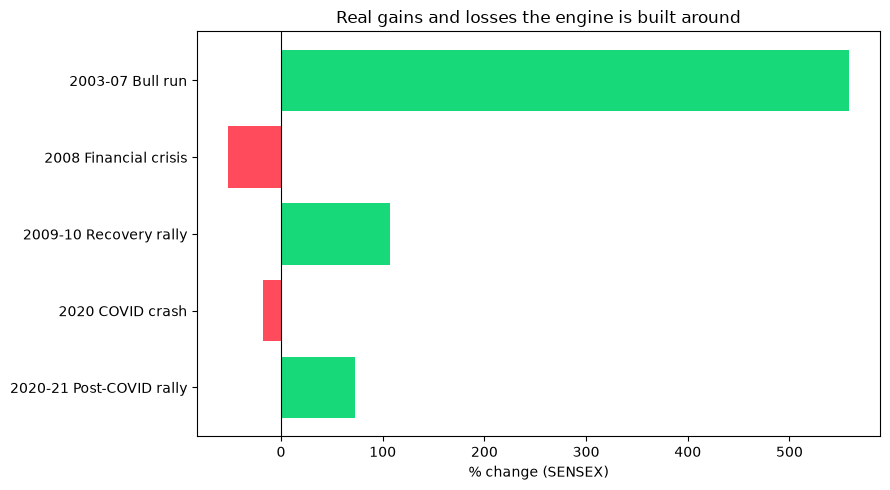

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#17D97A' if v >= 0 else '#FF4B5C' for v in events_df['pct_change']]
ax.barh(events_df['label'], events_df['pct_change'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% change (SENSEX)')
ax.set_title('Real gains and losses the engine is built around')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

`results/five_key_market_events.csv` -- the 5 chosen periods with real start/end dates, start/end SENSEX prices, verified start-to-end % change, and now also `max_drawdown_pct`/`max_runup_pct` (peak-to-trough and trough-to-peak within the window) with their dates. For the two crash events, `max_drawdown_pct` is likely the more standard number to show as the headline stat; for the three rally events, `pct_change` and `max_runup_pct` should end up close to each other since those periods are closer to monotonically increasing.

If any of the recomputed numbers still look meaningfully different from her original chart, that's worth flagging back to her -- the dates in Step 1 can be adjusted if she had more precise boundaries in mind.